1.Examine the movies.csv file and especially the genres column. There are just
over 85,000 movies and about 20 genres
2 clean data there were 17 null in tags which i removed
3. no scaling needed becouse when i check describe for rating scale were clean no outliers..
4. 

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

print("Current working directory:", Path.cwd())


def load_movielens_data():
    candidates = [
        Path("data"),
        Path("../data"),
        Path("lab1/data"),
        Path("data/ml-latest"),
        Path("../data/ml-latest"),
        Path("lab1/data/ml-latest"),
    ]

    for data_dir in candidates:
        if (data_dir / "movies.csv").exists() and (data_dir / "ratings.csv").exists() and (data_dir / "tags.csv").exists():
            movies = pd.read_csv(data_dir / "movies.csv")
            ratings = pd.read_csv(data_dir / "ratings.csv")
            tags = pd.read_csv(data_dir / "tags.csv")
            print(f"Loaded data from: {data_dir.resolve()}")
            return movies, ratings, tags

    checked = "\n".join(str(p.resolve()) for p in candidates)
    raise FileNotFoundError(
        "Could not find MovieLens files.\n"
        "Expected movies.csv, ratings.csv, and tags.csv in one of these locations:\n"
        f"{checked}"
    )

movies, ratings, tags = load_movielens_data()

for name, df in [("movies", movies), ("ratings", ratings), ("tags", tags)]:
    print(f"\n--- {name.upper()} ---")
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nInfo:")
    print(df.info())
    print("\nMissing values:")
    print(df.isna().sum())
    print("\nFirst 5 rows:")
    print(df.head())

Current working directory: c:\Users\horie\machine_learning\lab1\notebooks
Loaded data from: C:\Users\horie\machine_learning\lab1\data

--- MOVIES ---
Shape: (86537, 3)

Columns:
['movieId', 'title', 'genres']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 86537 entries, 0 to 86536
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  86537 non-null  int64
 1   title    86537 non-null  str  
 2   genres   86537 non-null  str  
dtypes: int64(1), str(2)
memory usage: 2.0 MB
None

Missing values:
movieId    0
title      0
genres     0
dtype: int64

First 5 rows:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation

Explore movies:

In [73]:
print("Number of unique movies:", movies["movieId"].nunique())
print("Number of unique titles:", movies["title"].nunique())

print("\nMost common full genre combinations:")
print(movies["genres"].value_counts().head(10))

print("\nMovies with '(no genres listed)':")
print((movies["genres"] == "(no genres listed)").sum())

all_genres = movies["genres"].str.split("|").explode()

print("\nNumber of unique individual genres:")
print(all_genres.nunique())

print("\nMost common individual genres:")
print(all_genres.value_counts().head(20))


Number of unique movies: 86537
Number of unique titles: 86330

Most common full genre combinations:
genres
Drama                   12246
Documentary              8064
Comedy                   7689
(no genres listed)       7060
Comedy|Drama             3196
Drama|Romance            2788
Horror                   2467
Comedy|Romance           2176
Thriller                 1397
Comedy|Drama|Romance     1310
Name: count, dtype: int64

Movies with '(no genres listed)':
7060

Number of unique individual genres:
20

Most common individual genres:
genres
Drama                 33681
Comedy                22830
Thriller              11675
Romance               10172
Action                 9563
Documentary            9283
Horror                 8570
(no genres listed)     7060
Crime                  6917
Adventure              5349
Sci-Fi                 4850
Animation              4579
Children               4367
Mystery                3972
Fantasy                3821
War                    2301


explore ratings:

In [74]:
print("Shape:", ratings.shape)
print("Number of unique users:", ratings["userId"].nunique())
print("Number of unique movies rated:", ratings["movieId"].nunique())

print("\nRating distribution:")
print(ratings["rating"].value_counts().sort_index())

print("\nSummary statistics:")
print(ratings["rating"].describe())

print("\nMinimum rating:", ratings["rating"].min())
print("Maximum rating:", ratings["rating"].max())

print("\nRatings per user:")
ratings_per_user = ratings.groupby("userId").size()
print(ratings_per_user.describe())

print("\nRatings per movie:")
ratings_per_movie = ratings.groupby("movieId").size()
print(ratings_per_movie.describe())


Shape: (33832162, 4)
Number of unique users: 330975
Number of unique movies rated: 83239

Rating distribution:
rating
0.5     566306
1.0    1013645
1.5     562409
2.0    2146492
2.5    1760733
3.0    6400664
3.5    4465001
4.0    8835955
4.5    3123055
5.0    4957902
Name: count, dtype: int64

Summary statistics:
count    3.383216e+07
mean     3.542540e+00
std      1.063959e+00
min      5.000000e-01
25%      3.000000e+00
50%      4.000000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

Minimum rating: 0.5
Maximum rating: 5.0

Ratings per user:
count    330975.00000
mean        102.21969
std         232.15453
min           1.00000
25%          15.00000
50%          31.00000
75%          98.00000
max       33332.00000
dtype: float64

Ratings per movie:
count     83239.000000
mean        406.446041
std        2806.975876
min           1.000000
25%           2.000000
50%           5.000000
75%          26.000000
max      122296.000000
dtype: float64


explore tags:

In [75]:
print("Shape:", tags.shape)
print("Number of unique users tagging:", tags["userId"].nunique())
print("Number of unique movies tagged:", tags["movieId"].nunique())

print("\nMissing tags:")
print(tags["tag"].isna().sum())

print("\nMost common tags:")
print(tags["tag"].value_counts().head(20))

tags_per_movie = tags.groupby("movieId").size()
print("\nTags per movie:")
print(tags_per_movie.describe())

tags_per_user = tags.groupby("userId").size()
print("\nTags per user:")
print(tags_per_user.describe())


Shape: (2328315, 4)
Number of unique users tagging: 25280
Number of unique movies tagged: 53452

Missing tags:
17

Most common tags:
tag
sci-fi                14319
atmospheric           12172
action                10683
comedy                10161
surreal                9142
funny                  9094
visually appealing     8890
twist ending           8325
thought-provoking      7727
dark comedy            7659
based on a book        7584
dystopia               6975
cinematography         6473
social commentary      6369
romance                6338
violence               6300
stylized               6163
psychology             6111
fantasy                6082
murder                 5955
Name: count, dtype: int64

Tags per movie:
count    53452.000000
mean        43.558988
std        197.466261
min          1.000000
25%          2.000000
50%          6.000000
75%         18.000000
max      11152.000000
dtype: float64

Tags per user:
count     25280.000000
mean         92.101068
std    

In [ ]:
ratings.head(5)


,userId,movieId,tag,timestamp
0,10,260,good vs evil,1430666558
1,10,260,Harrison Ford,1430666505
2,10,260,sci-fi,1430666538
3,14,1221,Al Pacino,1311600756
4,14,1221,mafia,1311600746


In [89]:
movies.head(5)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [90]:

tags.head(5)

,userId,movieId,tag,timestamp
0,10,260,good vs evil,1430666558
1,10,260,Harrison Ford,1430666505
2,10,260,sci-fi,1430666538
3,14,1221,Al Pacino,1311600756
4,14,1221,mafia,1311600746


In [76]:
movies.shape, ratings.shape, tags.shape


((86537, 3), (33832162, 4), (2328315, 4))

In [77]:
movies.genres.unique()

<StringArray>
[          'Adventure|Animation|Children|Comedy|Fantasy',
                            'Adventure|Children|Fantasy',
                                        'Comedy|Romance',
                                  'Comedy|Drama|Romance',
                                                'Comedy',
                                 'Action|Crime|Thriller',
                                    'Adventure|Children',
                                                'Action',
                             'Action|Adventure|Thriller',
                                         'Comedy|Horror',
 ...
                'Action|Animation|Comedy|Romance|Sci-Fi',
                       'Action|Animation|Romance|Sci-Fi',
                        'Animation|Children|Documentary',
                      'Crime|Documentary|Drama|Thriller',
             'Adventure|Fantasy|Horror|Mystery|Thriller',
 'Action|Adventure|Drama|Fantasy|Mystery|Romance|Sci-Fi',
                    'Adventure|Animation|Comedy|Weste

In [78]:
ratings['rating'].unique()

array([4. , 4.5, 5. , 3.5, 3. , 2. , 2.5, 1. , 1.5, 0.5])

In [79]:
movies .describe


<bound method NDFrame.describe of        movieId                                              title  \
0            1                                   Toy Story (1995)   
1            2                                     Jumanji (1995)   
2            3                            Grumpier Old Men (1995)   
3            4                           Waiting to Exhale (1995)   
4            5                 Father of the Bride Part II (1995)   
...        ...                                                ...   
86532   288967               State of Siege: Temple Attack (2021)   
86533   288971                                 Ouija Japan (2021)   
86534   288975   The Men Who Made the Movies: Howard Hawks (1973)   
86535   288977                    Skinford: Death Sentence (2023)   
86536   288983  UNZIPPED: An Autopsy of American Inequality (2...   

                                            genres  
0      Adventure|Animation|Children|Comedy|Fantasy  
1                       Adventu

In [80]:
dfs = {
    "Movies": movies,
    "Ratings": ratings,
    "Tags": tags
}

for name, df in dfs.items():
    print(f"\n{name} null values:\n{df.isnull().sum()}")


Movies null values:
movieId    0
title      0
genres     0
dtype: int64

Ratings null values:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Tags null values:
userId        0
movieId       0
tag          17
timestamp     0
dtype: int64


In [81]:
movies.columns

Index(['movieId', 'title', 'genres'], dtype='str')

Clean data

In [82]:
tags_option1 = tags.copy()
tags_option1.dropna(subset=['tag'], inplace=True)

# Show only the rows that originally had NaN
tags[tags['tag'].isna()]
tags_option1.isna().sum()

userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

In [83]:
ratings.describe()

,userId,movieId,rating,timestamp
count,3.383216e+07,3.383216e+07,3.383216e+07,3.383216e+07
mean,1.654380e+05,2.831348e+04,3.542540e+00,1.269362e+09
std,9.534122e+04,4.992865e+04,1.063959e+00,2.541023e+08
min,1.000000e+00,1.000000e+00,5.000000e-01,7.896520e+08
25%,8.295300e+04,1.219000e+03,3.000000e+00,1.046718e+09
50%,1.661290e+05,3.263000e+03,4.000000e+00,1.264740e+09
75%,2.474500e+05,4.049100e+04,4.000000e+00,1.496919e+09
max,3.309750e+05,2.889830e+05,5.000000e+00,1.689843e+09


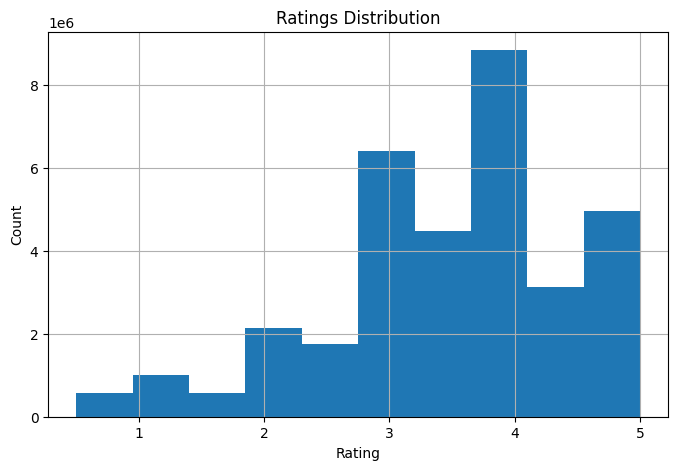

In [84]:
ratings['rating'].hist(bins=10, figsize=(8, 5))
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

1: Random samplin or
2: filter active users

In [85]:
#random sampling choose gives you ~3 million rows instead of 30 million.
ratings_small = ratings.sample(frac=0.1, random_state=42)

In [86]:
user_counts = ratings['userId'].value_counts()
active_users = user_counts[user_counts > 50].index
ratings_filtered = ratings[ratings['userId'].isin(active_users)]
print("Full dataset:", len(ratings))
print("Sampled dataset:", len(ratings_small))
print("Filtered dataset:", len(ratings_filtered))

Full dataset: 33832162
Sampled dataset: 3383216
Filtered dataset: 30064010


In [87]:
print("Full dataset:", len(ratings))
print("Sampled dataset:", len(ratings_small))
print("Filtered dataset:", len(ratings_filtered))

Full dataset: 33832162
Sampled dataset: 3383216
Filtered dataset: 30064010


clean tags:

In [94]:
tags_clean = tags.dropna(subset=["tag"]).copy()
tags_clean["tag"] = tags_clean["tag"].str.lower().str.strip()

movie_tags = (
    tags_clean.groupby("movieId")["tag"]
    .apply(lambda x: " ".join(x.astype(str)))
    .reset_index(name="tag_text")
)
movie_tags.head(10)

movie_ratings_summary = (
    ratings.groupby("movieId")["rating"]
    .agg(rating_count="count", avg_rating="mean")
    .reset_index()
)
movie_ratings_summary.head(10)
movie_data = (
    movies.merge(movie_tags, on="movieId", how="left")
          .merge(movie_ratings_summary, on="movieId", how="left")
)
movie_data.head(10)

movie_data["tag_text"] = movie_data["tag_text"].fillna("")
movie_data["rating_count"] = movie_data["rating_count"].fillna(0)
movie_data["avg_rating"] = movie_data["avg_rating"].fillna(0)
movie_data.head(10)

,movieId,title,genres,tag_text,rating_count,avg_rating
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,animation friendship toys animation disney pix...,76813.0,3.893508
1,2,Jumanji (1995),Adventure|Children|Fantasy,animals based on a book fantasy magic board ga...,30209.0,3.278179
2,3,Grumpier Old Men (1995),Comedy|Romance,sequel moldy old old age old men wedding old p...,15820.0,3.171271
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,characters chick flick girl movie characters c...,3028.0,2.868395
4,5,Father of the Bride Part II (1995),Comedy,family pregnancy wedding 4th wall aging baby d...,15801.0,3.076957
5,6,Heat (1995),Action|Crime|Thriller,al pacino complex characters crime philosophy ...,31850.0,3.862166
6,7,Sabrina (1995),Comedy|Romance,based on a play harrison ford paris romance si...,15596.0,3.372339
7,8,Tom and Huck (1995),Adventure|Children,adapted from:book author:mark twain prospect p...,1584.0,3.118056
8,9,Sudden Death (1995),Action,jean-claude van damme can't remember clv 1990s...,4563.0,3.003178
9,10,GoldenEye (1995),Action|Adventure|Thriller,its an ok movie if you like james bound. 007 ...,34942.0,3.434835


In [95]:
movie_ids_movies = set(movies["movieId"])
movie_ids_ratings = set(ratings["movieId"])
movie_ids_tags = set(tags["movieId"])

print("Movies in movies.csv:", len(movie_ids_movies))
print("Movies appearing in ratings.csv:", len(movie_ids_ratings))
print("Movies appearing in tags.csv:", len(movie_ids_tags))

print("\nMovies in both movies and ratings:")
print(len(movie_ids_movies & movie_ids_ratings))

print("\nMovies in both movies and tags:")
print(len(movie_ids_movies & movie_ids_tags))

print("\nMovies in all three files:")
print(len(movie_ids_movies & movie_ids_ratings & movie_ids_tags))

print("\nMovies with no ratings:")
print(len(movie_ids_movies - movie_ids_ratings))

print("\nMovies with no tags:")
print(len(movie_ids_movies - movie_ids_tags))


Movies in movies.csv: 86537
Movies appearing in ratings.csv: 83239
Movies appearing in tags.csv: 53452

Movies in both movies and ratings:
83239

Movies in both movies and tags:
53452

Movies in all three files:
50154

Movies with no ratings:
3298

Movies with no tags:
33085


heck how the files connect through movieId:

In [96]:
movie_ids_movies = set(movies["movieId"])
movie_ids_ratings = set(ratings["movieId"])
movie_ids_tags = set(tags["movieId"])

print("Movies in movies.csv:", len(movie_ids_movies))
print("Movies appearing in ratings.csv:", len(movie_ids_ratings))
print("Movies appearing in tags.csv:", len(movie_ids_tags))

print("\nMovies in both movies and ratings:")
print(len(movie_ids_movies & movie_ids_ratings))

print("\nMovies in both movies and tags:")
print(len(movie_ids_movies & movie_ids_tags))

print("\nMovies in all three files:")
print(len(movie_ids_movies & movie_ids_ratings & movie_ids_tags))

print("\nMovies with no ratings:")
print(len(movie_ids_movies - movie_ids_ratings))

print("\nMovies with no tags:")
print(len(movie_ids_movies - movie_ids_tags))


Movies in movies.csv: 86537
Movies appearing in ratings.csv: 83239
Movies appearing in tags.csv: 53452

Movies in both movies and ratings:
83239

Movies in both movies and tags:
53452

Movies in all three files:
50154

Movies with no ratings:
3298

Movies with no tags:
33085


look at whether userId is useful for your first project, or whether we should stay movie-focused:

In [97]:
user_ids_ratings = set(ratings["userId"])
user_ids_tags = set(tags["userId"])

print("Users in ratings.csv:", len(user_ids_ratings))
print("Users in tags.csv:", len(user_ids_tags))

print("\nUsers in both ratings and tags:")
print(len(user_ids_ratings & user_ids_tags))

print("\nUsers only in ratings:")
print(len(user_ids_ratings - user_ids_tags))

print("\nUsers only in tags:")
print(len(user_ids_tags - user_ids_ratings))


Users in ratings.csv: 330975
Users in tags.csv: 25280

Users in both ratings and tags:
25280

Users only in ratings:
305695

Users only in tags:
0


In [100]:
tags_clean = tags.dropna(subset=["tag"]).copy()
tags_clean["tag"] = tags_clean["tag"].str.lower().str.strip()
tags_clean = tags_clean[tags_clean["tag"] != ""]
movies_with_tags = tags["movieId"].nunique()
movies_with_ratings = ratings["movieId"].nunique()
total_movies = movies["movieId"].nunique()

print("Total movies:", total_movies)
print("Movies with ratings:", movies_with_ratings)
print("Movies with tags:", movies_with_tags)

print("\nPercentage of movies with ratings:")
print(round(movies_with_ratings / total_movies * 100, 2), "%")

print("\nPercentage of movies with tags:")
print(round(movies_with_tags / total_movies * 100, 2), "%")


Total movies: 86537
Movies with ratings: 83239
Movies with tags: 53452

Percentage of movies with ratings:
96.19 %

Percentage of movies with tags:
61.77 %


In [101]:
movies["genres_clean"] = (
    movies["genres"]
    .str.replace("|", " ", regex=False)
    .str.lower()
    .str.strip()
)

print(movies[["title", "genres", "genres_clean"]].head(10))


                                title  \
0                    Toy Story (1995)   
1                      Jumanji (1995)   
2             Grumpier Old Men (1995)   
3            Waiting to Exhale (1995)   
4  Father of the Bride Part II (1995)   
5                         Heat (1995)   
6                      Sabrina (1995)   
7                 Tom and Huck (1995)   
8                 Sudden Death (1995)   
9                    GoldenEye (1995)   

                                        genres  \
0  Adventure|Animation|Children|Comedy|Fantasy   
1                   Adventure|Children|Fantasy   
2                               Comedy|Romance   
3                         Comedy|Drama|Romance   
4                                       Comedy   
5                        Action|Crime|Thriller   
6                               Comedy|Romance   
7                           Adventure|Children   
8                                       Action   
9                    Action|Adventure|Thriller  

In [102]:
tags_clean = tags.dropna(subset=["tag"]).copy()
tags_clean["tag"] = tags_clean["tag"].str.lower().str.strip()
tags_clean = tags_clean[tags_clean["tag"] != ""]

movie_tags = (
    tags_clean.groupby("movieId")["tag"]
    .apply(lambda x: " ".join(x))
    .reset_index(name="tag_text")
)

movies_explore = movies.merge(movie_tags, on="movieId", how="left")
movies_explore["tag_text"] = movies_explore["tag_text"].fillna("")

movies_explore["genres_clean"] = (
    movies_explore["genres"]
    .str.replace("|", " ", regex=False)
    .str.lower()
    .str.strip()
)

movies_explore["text_features"] = (
    movies_explore["genres_clean"] + " " + movies_explore["tag_text"]
).str.strip()

print(movies_explore[["movieId", "title", "genres_clean", "tag_text", "text_features"]].head(10))


   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   
5        6                         Heat (1995)   
6        7                      Sabrina (1995)   
7        8                 Tom and Huck (1995)   
8        9                 Sudden Death (1995)   
9       10                    GoldenEye (1995)   

                                  genres_clean  \
0  adventure animation children comedy fantasy   
1                   adventure children fantasy   
2                               comedy romance   
3                         comedy drama romance   
4                                       comedy   
5                        action crime thriller   
6                               comedy romance   
7                           adventure children   

In [103]:
tags_clean = tags.dropna(subset=["tag"]).copy()
tags_clean["tag"] = tags_clean["tag"].str.lower().str.strip()
tags_clean = tags_clean[tags_clean["tag"] != ""]

movie_tags = (
    tags_clean.groupby("movieId")["tag"]
    .apply(lambda x: " ".join(x))
    .reset_index(name="tag_text")
)

rating_summary = (
    ratings.groupby("movieId")["rating"]
    .agg(rating_count="count", avg_rating="mean")
    .reset_index()
)

movie_data = (
    movies.copy()
    .merge(movie_tags, on="movieId", how="left")
    .merge(rating_summary, on="movieId", how="left")
)

movie_data["tag_text"] = movie_data["tag_text"].fillna("")
movie_data["rating_count"] = movie_data["rating_count"].fillna(0)
movie_data["avg_rating"] = movie_data["avg_rating"].fillna(0)

movie_data["genres_clean"] = (
    movie_data["genres"]
    .str.replace("|", " ", regex=False)
    .str.lower()
    .str.strip()
)

movie_data["text_features"] = (
    movie_data["genres_clean"] + " " + movie_data["tag_text"]
).str.strip()

print(movie_data[["movieId", "title", "genres_clean", "tag_text", "rating_count", "avg_rating", "text_features"]].head())
print(movie_data.shape)


   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                  genres_clean  \
0  adventure animation children comedy fantasy   
1                   adventure children fantasy   
2                               comedy romance   
3                         comedy drama romance   
4                                       comedy   

                                            tag_text  rating_count  \
0  animation friendship toys animation disney pix...       76813.0   
1  animals based on a book fantasy magic board ga...       30209.0   
2  sequel moldy old old age old men wedding old p...       15820.0   
3  characters chick flick girl movie characters c...        3028.0   
4  family pregnancy wedding 4th wall aging baby 

In [ ]:
#Turn text_features into TF-IDF vectors
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(movie_data["text_features"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)


TF-IDF matrix shape: (86537, 51797)


i have 86537 movies
my text_creater 51797 unique terms

In [106]:
from sklearn.metrics.pairwise import linear_kernel

indices = pd.Series(movie_data.index, index=movie_data["title"]).drop_duplicates()

def recommend_movies(title, n=5):
    if title not in indices:
        return f"Movie '{title}' not found."

    idx = indices[title]

    sim_scores = linear_kernel(tfidf_matrix[idx:idx+1], tfidf_matrix).flatten()
    sim_indices = sim_scores.argsort()[::-1][1:n+1]

    return movie_data.iloc[sim_indices][["title", "avg_rating", "rating_count"]]
recommend_movies("Toy Story (1995)")


,title,avg_rating,rating_count
3021,Toy Story 2 (1999),3.809132,34495.0
2264,"Bug's Life, A (1998)",3.559332,28290.0
14815,Toy Story 3 (2010),3.832119,21131.0
39883,Finding Dory (2016),3.541535,5706.0
4781,"Monsters, Inc. (2001)",3.840528,48441.0
